<a href="https://colab.research.google.com/github/UXDynamicSolution/MineriaDatosDuocPAO/blob/main/material_reforzamiento_arboles_decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árboles de Decisión

## Material de reforzamiento elaborado por Carlos Muñoz Salgado

Existen dos grandes categorías para este modelo:

### Árboles de Regresión
Nos permiten trabajar con variables numéricas (continuas).

En el caso de los **árboles de regresión**, podríamos predecir cuántos mm lloverá en base a parámetros como temperatura, humedad, presión, etc.

---

### Árboles de Clasificación
Se utilizan para predecir una clase (variable categórica representada numéricamente o codificada).

En el caso de los **árboles de clasificación**, usando los mismos parámetros anteriores, podríamos predecir si lloverá o no (variable binaria). (SI/NO) (0/1)

---

## Recordemos algo importante y tengámoslo presente

> "Si realizamos un buen analisis exploratorio, conocemos el negocio, nuestros datos y entendemos como funciona el modelo, lo podemos aplicar."

# Para aplicar estos modelos, de forma ilustrativa, lo haremos para el siguiente caso: determinar si lloverá o no, cuanto lloverá en Santiago, primeramente utilizando un dataset para entrenar y posteriormente usando un API con datos en tiempo real

# Mapeo de Datos: Dataset Meteorológico Las Vizcachas

**- timestamp:** Fecha y hora exacta del registro meteorológico.

**- temp_surface:** Temperatura ambiente a nivel del suelo medida en grados Celsius.

**- pressure_surface:** Presión atmosférica en superficie (hPa). Es el principal indicador de la llegada de frentes de baja presión.

**- rh_surface:** Humedad relativa del aire (%). Indica el nivel de saturación de vapor de agua en el ambiente.

**- wind_speed_850h:** Velocidad del viento a una altitud de 850hPa (aprox. 1.500 msnm). Crucial para detectar el desplazamiento de masas de aire en la precordillera.

**- lluvia_mm:** Variable Objetivo (Target) para modelos de Regresión. Representa la cantidad de agua caída en milímetros.

**- llovera_bin:** Variable Objetivo (Target) para modelos de Clasificación. Valor binario donde 1 indica lluvia y 0 indica tiempo seco.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("clima_las_vizcachas_train.csv")
df.head()

,timestamp,temp_surface,pressure_surface,rh_surface,wind_speed_850h,lluvia_mm,llovera_bin
0,2026-04-20 00:00:00,16.126343,1012.046573,40.691343,12.447826,0.0,0
1,2026-04-20 01:00:00,15.599172,1010.848561,45.548343,7.383807,0.0,0
2,2026-04-20 02:00:00,10.669677,1014.944434,58.228092,8.267327,0.0,0
3,2026-04-20 03:00:00,16.557774,1012.018851,51.017301,7.850991,0.0,0
4,2026-04-20 04:00:00,14.173568,1013.222217,34.941816,14.923388,0.0,0


In [3]:
df.dtypes

,0
timestamp,object
temp_surface,float64
pressure_surface,float64
rh_surface,float64
wind_speed_850h,float64
lluvia_mm,float64
llovera_bin,int64


In [4]:
df.isnull().sum()

,0
timestamp,0
temp_surface,0
pressure_surface,0
rh_surface,0
wind_speed_850h,0
lluvia_mm,0
llovera_bin,0


In [5]:
df['llovera_bin'].value_counts()

,count
llovera_bin,
0,241
1,119


In [6]:
df.describe()

,temp_surface,pressure_surface,rh_surface,wind_speed_850h,lluvia_mm,llovera_bin
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,13.413316,1010.235397,60.209292,18.733685,1.234611,0.330556
std,2.997347,4.672306,23.045244,13.653714,2.419784,0.471068
min,7.307960,998.519530,30.075503,5.041554,0.000000,0.000000
25%,10.546392,1006.432840,40.628115,8.254891,0.000000,0.000000
50%,13.756583,1011.851568,53.199239,12.231345,0.000000,0.000000
75%,15.775839,1013.957958,85.665957,30.828921,1.837500,1.000000
max,20.608457,1017.980071,99.747583,49.051030,12.910000,1.000000


array([[<Axes: title={'center': 'temp_surface'}>,
        <Axes: title={'center': 'pressure_surface'}>],
       [<Axes: title={'center': 'rh_surface'}>,
        <Axes: title={'center': 'wind_speed_850h'}>],
       [<Axes: title={'center': 'lluvia_mm'}>,
        <Axes: title={'center': 'llovera_bin'}>]], dtype=object)

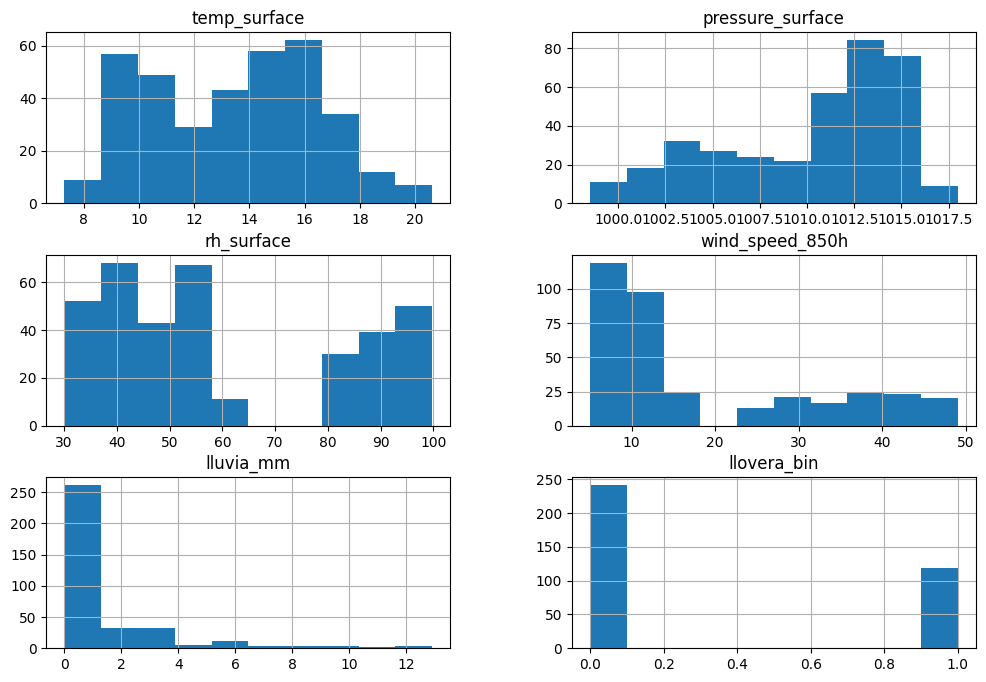

In [7]:
df.drop(['timestamp'], axis=1).hist(figsize=(12, 8)) # Creamos un gráfico sencillo para explorar la distribucion de los datos

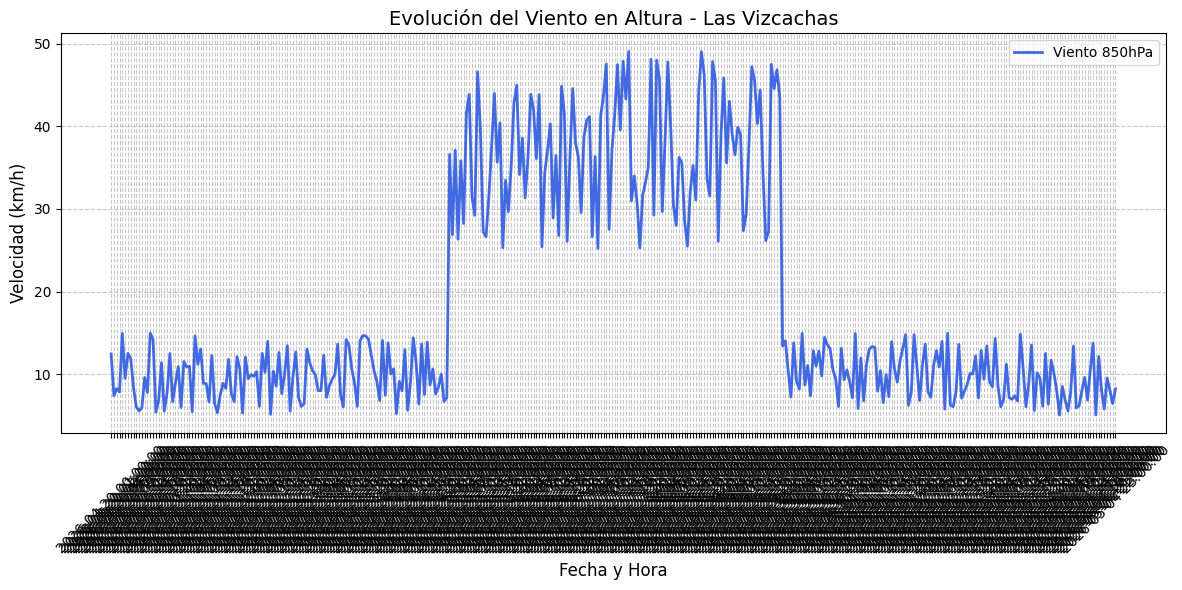

In [8]:
df = df.sort_values('timestamp')

# 2. Definimos los ejes (Tiempo en X, Viento en Y)
xpoints = df['timestamp']
ypoints = df['wind_speed_850h']

# 3. Creamos el gráfico con estilo
plt.figure(figsize=(12, 6))
plt.plot(xpoints, ypoints, color='royalblue', linewidth=2, label='Viento 850hPa')

# 4. Formato y etiquetas
plt.title('Evolución del Viento en Altura - Las Vizcachas', fontsize=14)
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Velocidad (km/h)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotar fechas para que no se amontonen
plt.legend()

plt.tight_layout()
plt.show()

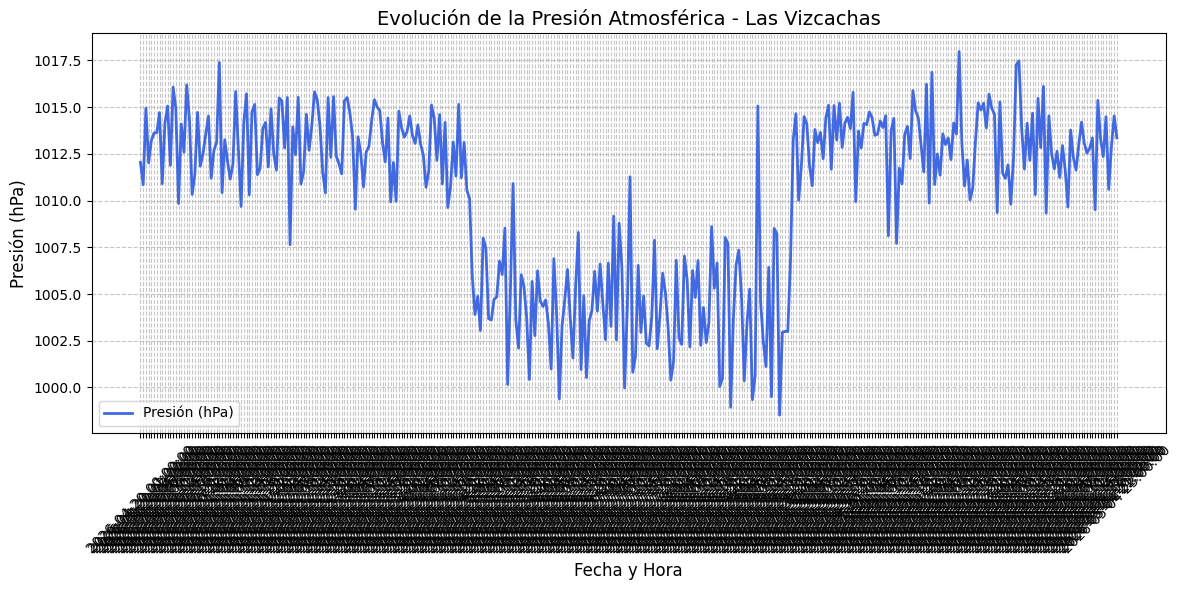

In [9]:
xpoints = df['timestamp']
ypoints = df['pressure_surface']

plt.figure(figsize=(12, 6))
plt.plot(xpoints, ypoints, color='royalblue', linewidth=2, label='Presión (hPa)')

plt.title('Evolución de la Presión Atmosférica - Las Vizcachas', fontsize=14)
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Presión (hPa)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

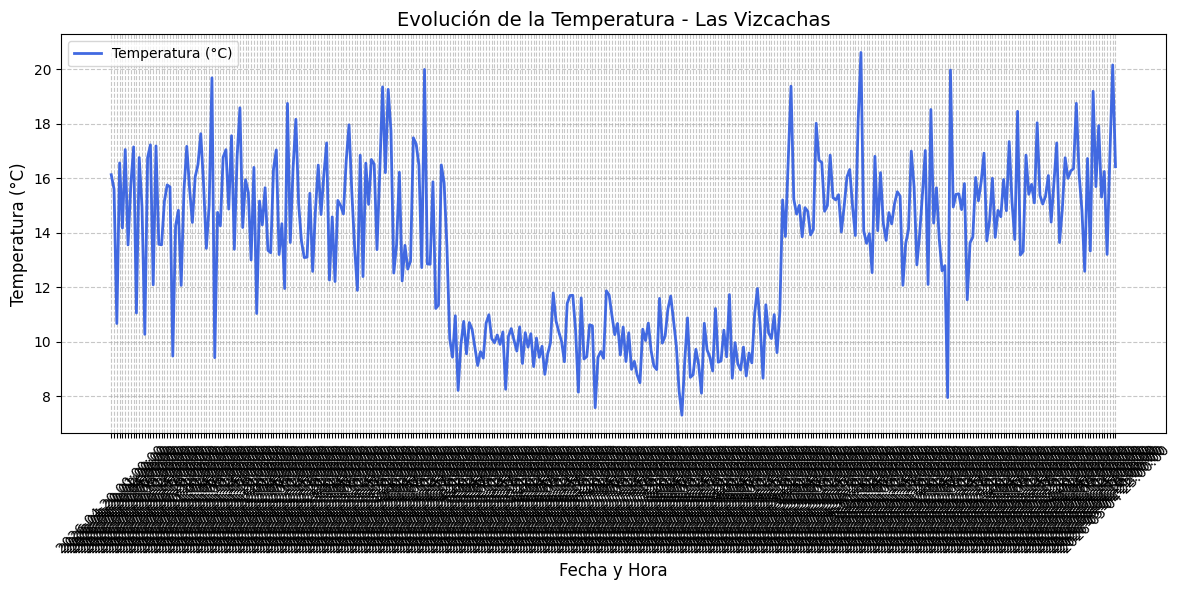

In [10]:
xpoints = df['timestamp']
ypoints = df['temp_surface']

plt.figure(figsize=(12, 6))
plt.plot(xpoints, ypoints, color='royalblue', linewidth=2, label='Temperatura (°C)')

plt.title('Evolución de la Temperatura - Las Vizcachas', fontsize=14)
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

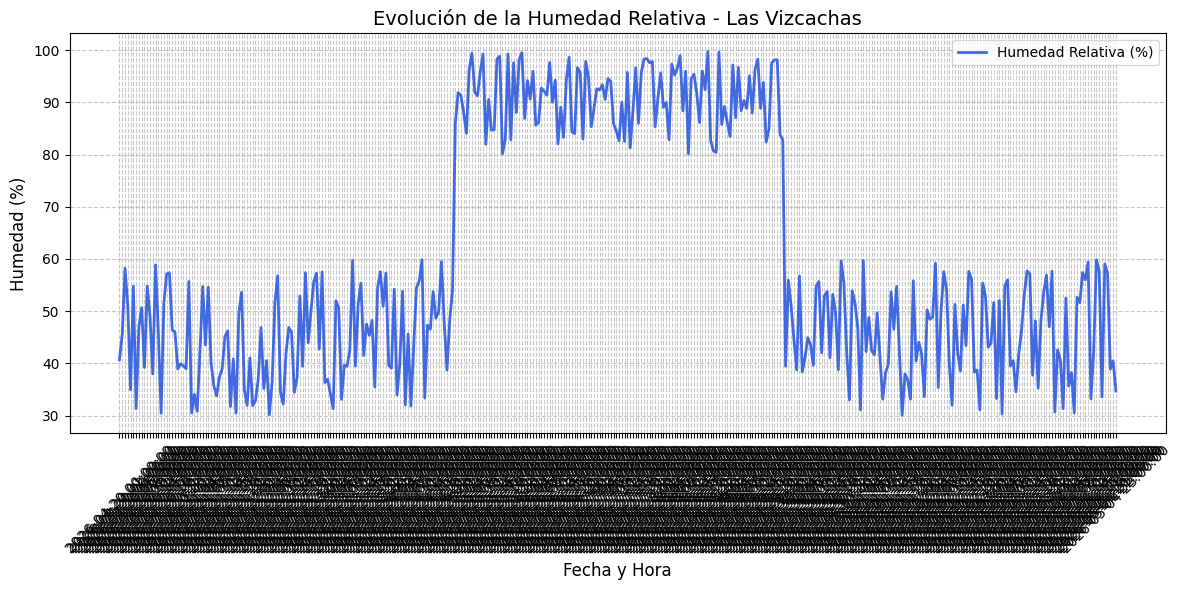

In [11]:
xpoints = df['timestamp']
ypoints = df['rh_surface']

plt.figure(figsize=(12, 6))
plt.plot(xpoints, ypoints, color='royalblue', linewidth=2, label='Humedad Relativa (%)')

plt.title('Evolución de la Humedad Relativa - Las Vizcachas', fontsize=14)
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Humedad (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

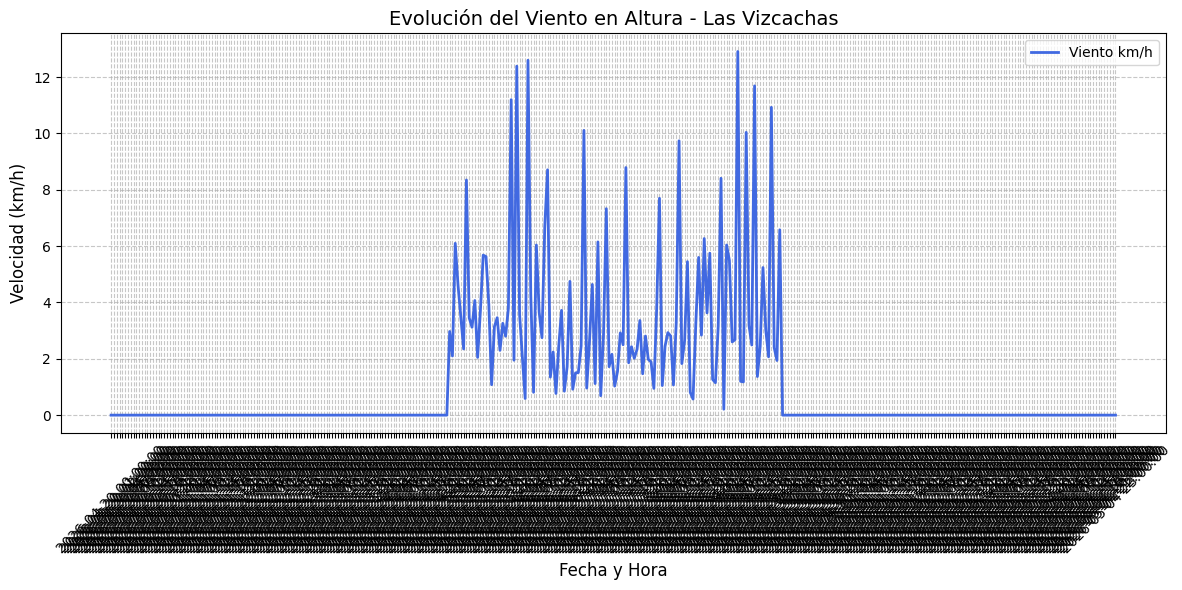

In [12]:
# 2. Definimos los ejes (Tiempo en X, Viento en Y)
xpoints = df['timestamp']
ypoints = df['lluvia_mm']

# 3. Creamos el gráfico con estilo
plt.figure(figsize=(12, 6))
plt.plot(xpoints, ypoints, color='royalblue', linewidth=2, label='Viento km/h')

# 4. Formato y etiquetas
plt.title('Evolución del Viento en Altura - Las Vizcachas', fontsize=14)
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Velocidad (km/h)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotar fechas para que no se amontonen
plt.legend()

plt.tight_layout()
plt.show()

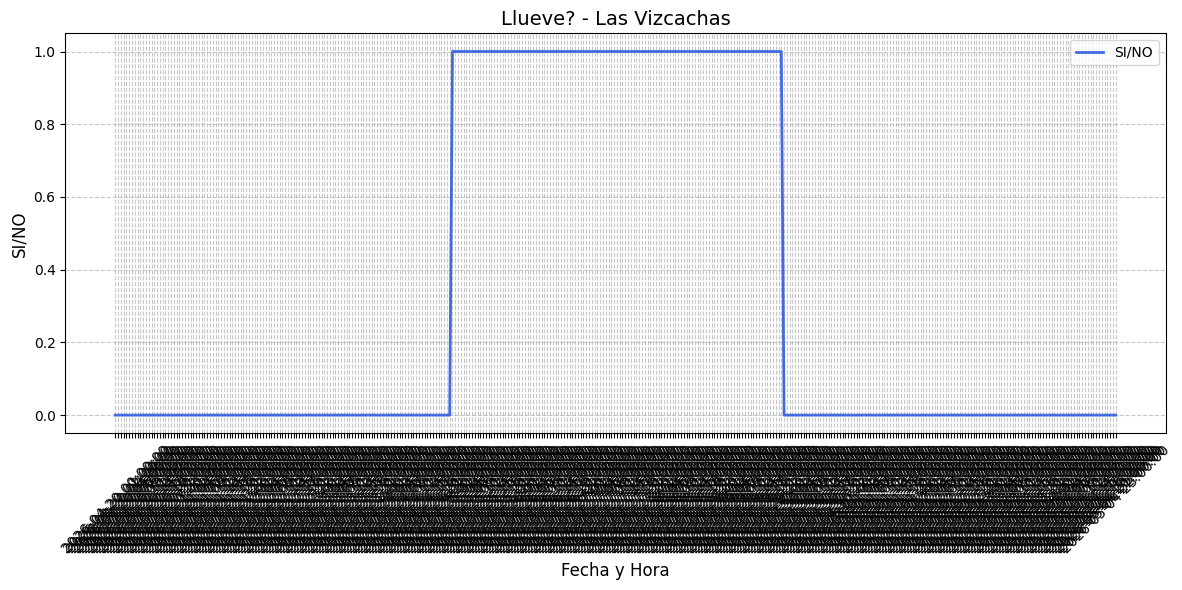

In [13]:
xpoints = df['timestamp']
ypoints = df['llovera_bin']

# 3. Creamos el gráfico con estilo
plt.figure(figsize=(12, 6))
plt.plot(xpoints, ypoints, color='royalblue', linewidth=2, label='SI/NO')

# 4. Formato y etiquetas
plt.title('Llueve? - Las Vizcachas', fontsize=14)
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('SI/NO', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotar fechas para que no se amontonen
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
corr = df.corr(numeric_only=True)

In [15]:
corr

,temp_surface,pressure_surface,rh_surface,wind_speed_850h,lluvia_mm,llovera_bin
temp_surface,1.000000,0.707513,-0.766442,-0.758257,-0.594481,-0.812787
pressure_surface,0.707513,1.000000,-0.822683,-0.825202,-0.611190,-0.876545
rh_surface,-0.766442,-0.822683,1.000000,0.882832,0.691567,0.939122
wind_speed_850h,-0.758257,-0.825202,0.882832,1.000000,0.699880,0.939874
lluvia_mm,-0.594481,-0.611190,0.691567,0.699880,1.000000,0.727098
llovera_bin,-0.812787,-0.876545,0.939122,0.939874,0.727098,1.000000


<Axes: title={'center': 'Pearson Correlation of Features'}>

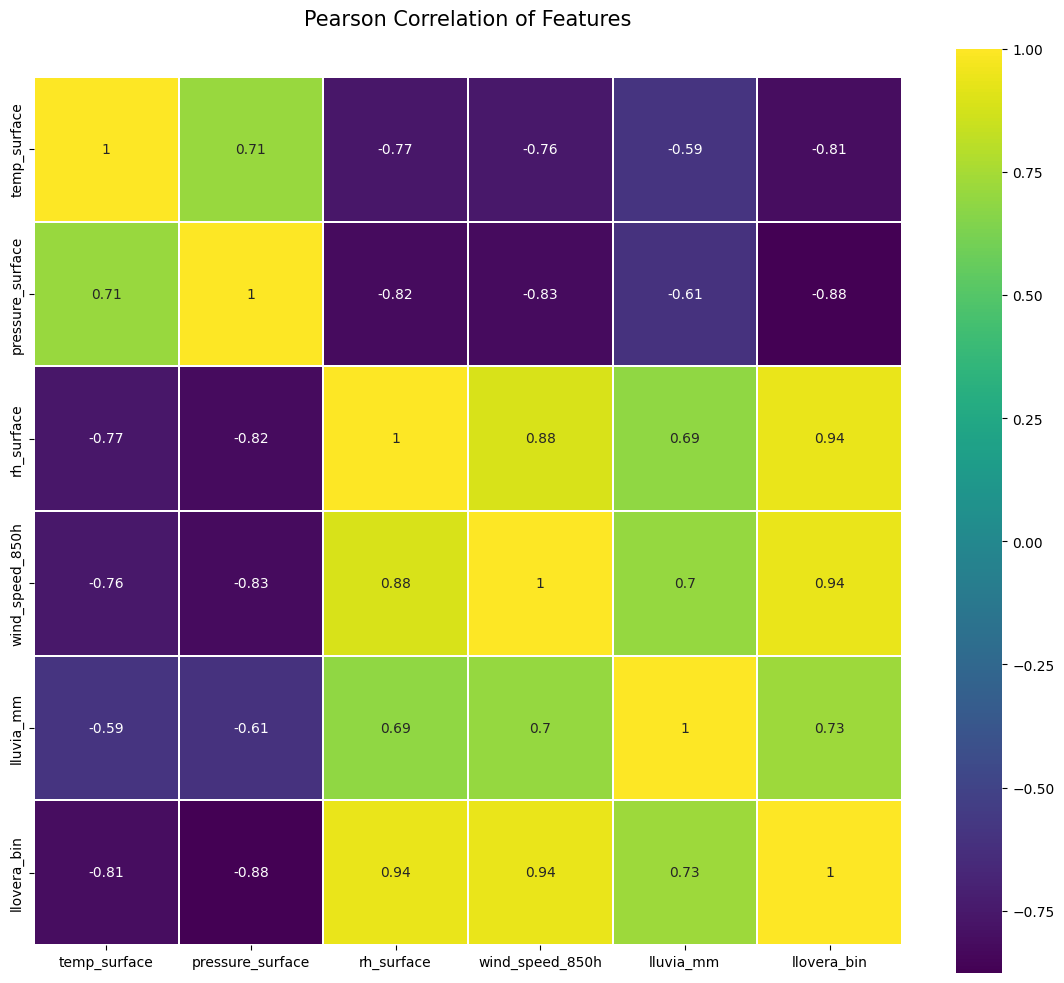

In [16]:

colormap = plt.cm.viridis
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(corr,
           linewidths=0.1,vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=True)

In [17]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# Preparar datos
X = df[['temp_surface', 'rh_surface', 'wind_speed_850h']]

# 1. Aplicar Regresor
reg_model = DecisionTreeRegressor(max_depth=5)
reg_model.fit(X, df['lluvia_mm']) # Predice cantidad de agua

DecisionTreeRegressor(max_depth=5)

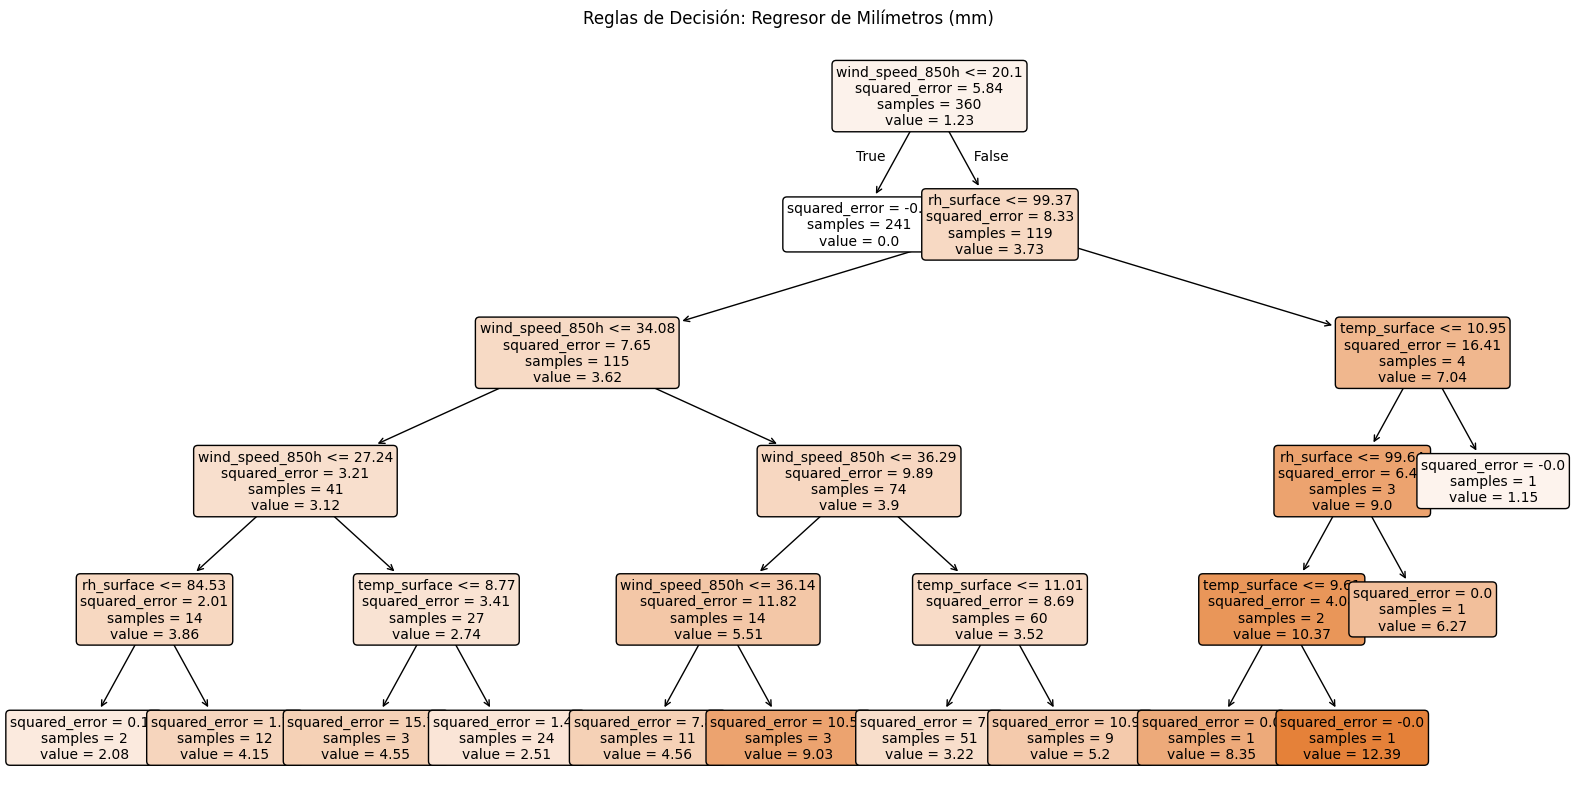

In [18]:
plt.figure(figsize=(20, 10))

# Dibujamos el árbol de regresión
plot_tree(reg_model,
          feature_names=['temp_surface', 'rh_surface', 'wind_speed_850h'],
          filled=True,
          rounded=True,
          precision=2,
          fontsize=10)

plt.title("Reglas de Decisión: Regresor de Milímetros (mm)")
plt.show()

In [19]:
# 2. Aplicar Clasificador
clf_model = DecisionTreeClassifier(max_depth=3)
clf_model.fit(X, df['llovera_bin']) # Predice SI (1) o NO (0)

DecisionTreeClassifier(max_depth=3)

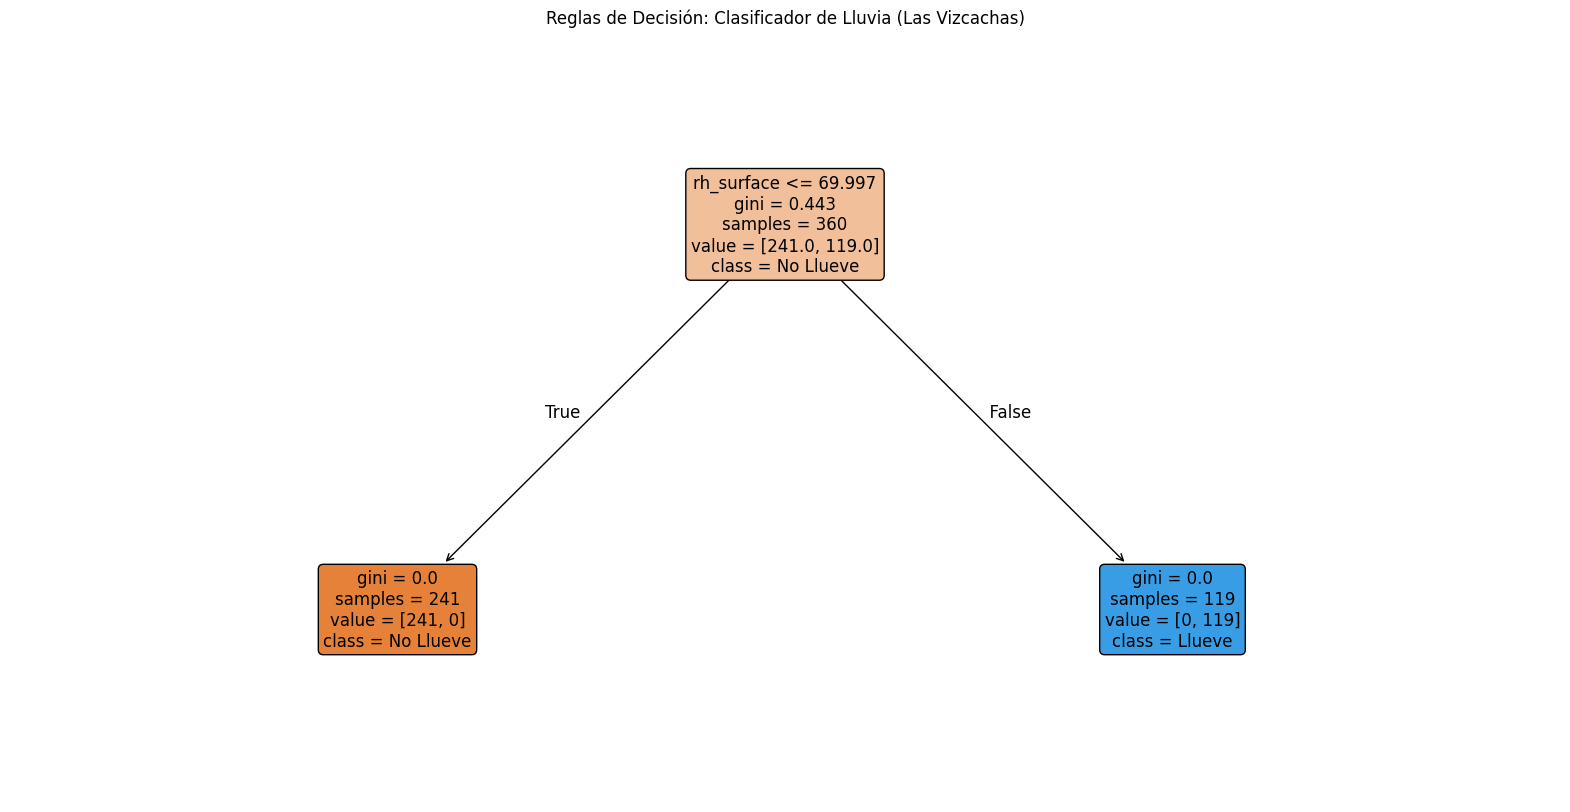

In [20]:
# Configuramos el tamaño del gráfico
plt.figure(figsize=(20, 10))

# Dibujamos el árbol de clasificación
plot_tree(clf_model,
          feature_names=['temp_surface', 'rh_surface', 'wind_speed_850h'],
          class_names=['No Llueve', 'Llueve'],
          filled=True,
          rounded=True,
          fontsize=12)

plt.title("Reglas de Decisión: Clasificador de Lluvia (Las Vizcachas)")
plt.show()

## Elementos de un Nodo en un Árbol de Decisión


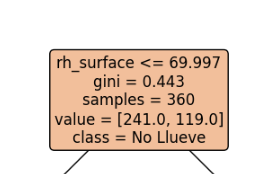

### Primera línea (Condición/Pregunta)
Es la regla de decisión. El árbol pregunta si el valor de esa columna es menor o igual a un número. Si se cumple, el dato se va hacia la izquierda; si no, hacia la derecha.

### gini (Impureza)
Representa el nivel de "desorden" del nodo.

- Si es 0, el nodo es perfecto (todos los datos son de una misma categoría).
- Entre más alto sea el número (máximo 0.5 en binario), más mezcladas están las categorías en ese punto.

### samples (Total de casos)
Indica cuántos registros o filas llegaron a este nodo. En tu imagen, hay 360 datos en total en este grupo.

### value (Conteo por categoría)
Muestra cuántos datos hay de cada clase.

- En el ejemplo `[241, 119]`, hay 241 casos de la primera categoría y 119 de la segunda.

### class (Resultado mayoritario)
Es la categoría ganadora en este nodo. Si el árbol tuviera que dar una respuesta aquí mismo, elegiría esta clase porque es la que tiene más cantidad en el `value`.

## Resumen

"De 360 casos, 241 son de una categoría y 119 de otra. Como la mayoría pertenece a la primera, la respuesta es No Llueve, pero hay un desorden (gini) de 0.443 porque todavía están algo mezclados."

In [21]:
from sklearn.model_selection import train_test_split

# Seleccionamos las variables que explican el fenómeno
X = df[['temp_surface', 'pressure_surface', 'rh_surface', 'wind_speed_850h']]

# Definimos los dos objetivos distintos
y_clasificacion = df['llovera_bin']  # ¿Lloverá? (1/0)
y_regresion = df['lluvia_mm']       # ¿Cuánto lloverá? (mm)

# Dividimos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_clasificacion, test_size=0.2, random_state=42)
_, _, y_train_reg, y_test_reg = train_test_split(X, y_regresion, test_size=0.2, random_state=42)

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Crear el modelo
clf = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Entrenar (Fit)
clf.fit(X_train, y_train_clf)

# 3. Predecir (Predict)
preds_clf = clf.predict(X_test)

# 4. Evaluar
print(f"Precisión del Clasificador: {accuracy_score(y_test_clf, preds_clf):.2%}")

Precisión del Clasificador: 100.00%


Importancia de Caracteristicas (Feature Importance)
Este codigo permite visualizar que variables (como la humedad o la presion) fueron las que mas peso tuvieron en las decisiones del arbol.

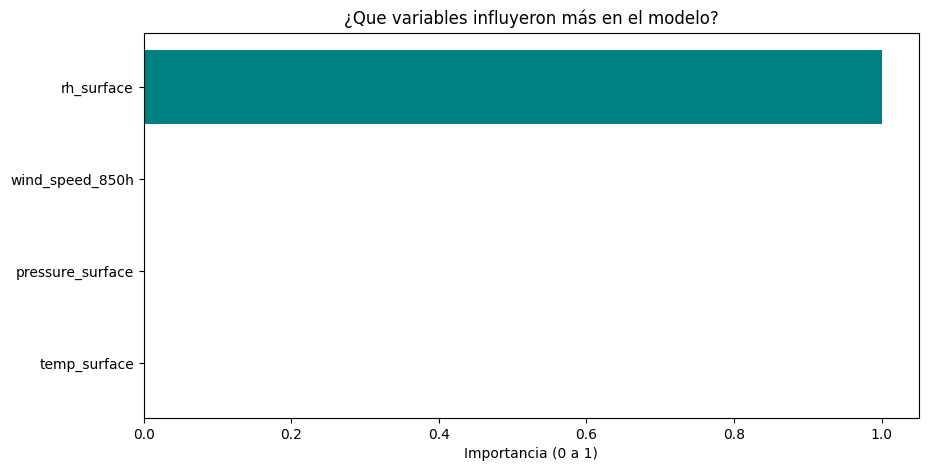

In [23]:
# 1. Obtener la importancia de cada columna
importancias = clf.feature_importances_
columnas = ['temp_surface', 'pressure_surface', 'rh_surface', 'wind_speed_850h']

# 2. Crear un DataFrame para graficar mejor
df_importancia = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values('Importancia', ascending=True)

# 3. Graficar
plt.figure(figsize=(10, 5))
plt.barh(df_importancia['Variable'], df_importancia['Importancia'], color='teal')
plt.title('¿Que variables influyeron más en el modelo?')
plt.xlabel('Importancia (0 a 1)')
plt.show()

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# 1. Crear el modelo
reg = DecisionTreeRegressor(max_depth=5, random_state=42)

# 2. Entrenar (Fit)
reg.fit(X_train, y_train_reg)

# 3. Predecir (Predict)
preds_reg = reg.predict(X_test)

# 4. Evaluar (Error medio en milímetros)
print(f"Error promedio (MAE): {mean_absolute_error(y_test_reg, preds_reg):.2f} mm")

Error promedio (MAE): 0.69 mm


Interpretación del MAE: En el regresor, un MAE de 0.50 significa que, en promedio, el modelo se equivoca por medio milímetro en sus predicciones.

# MATRIZ DE CONFUSIÓN

<Figure size 800x600 with 0 Axes>

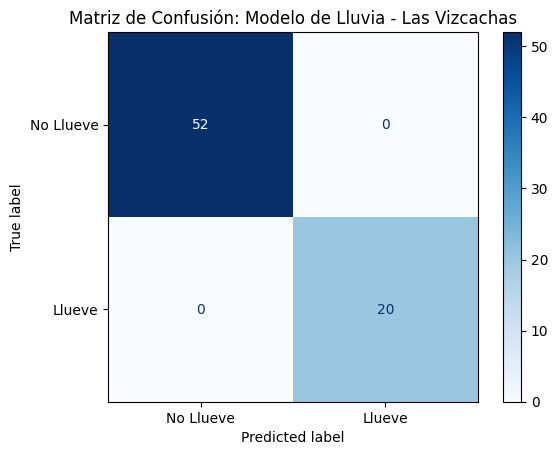

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Calculamos la matriz comparando lo real vs lo predicho
cm = confusion_matrix(y_test_clf, preds_clf)

# 2. Creamos la visualización
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Llueve', 'Llueve'])

# 3. Dibujamos
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión: Modelo de Lluvia - Las Vizcachas")
plt.show()

## Resultados de una Matriz de Confusión

### Verdaderos Negativos (TN)
El modelo dijo "No llueve" y efectivamente hubo sol. Todo bien.

### Verdaderos Positivos (TP)
El modelo dijo "Llueve" y cayó agua. ¡Éxito total!

### Falsos Positivos (FP - Error Tipo I)
El modelo predijo lluvia, pero no llovió. Consecuencia: Los alumnos llevaron paraguas por las puras.

### Falsos Negativos (FN - Error Tipo II)
El modelo dijo "No llueve", pero terminó lloviendo. Consecuencia: ¡Todos mojados! Este es el error más crítico en este contexto.

# "Si estuviéramos planeando un vuelo en parapente desde el San Ramón, ¿qué error preferirían cometer: un Falso Positivo o un Falso Negativo?".

In [26]:
from sklearn.metrics import classification_report

# Generamos el reporte comparando los datos reales del test con nuestras predicciones
reporte = classification_report(y_test_clf, preds_clf, target_names=['No Llueve', 'Llueve'])

print("--- Reporte de Desempeño del Modelo ---")
print(reporte)

--- Reporte de Desempeño del Modelo ---
              precision    recall  f1-score   support

   No Llueve       1.00      1.00      1.00        52
      Llueve       1.00      1.00      1.00        20

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



**Precision (Precisión):** "De todas las veces que el modelo dijo que llovería, ¿cuántas realmente llovió?". Una precisión alta en la clase 'Llueve' significa que el modelo no da falsas alarmas (pocos Falsos Positivos).

**Recall (Sensibilidad/Exhaustividad):** "De todos los días que llovió de verdad, ¿cuántos logró detectar el modelo?". Un recall alto significa que no se nos escapó ninguna tormenta (pocos Falsos Negativos).

**F1-Score: Es el equilibrio (media armónica)** entre los dos anteriores. Es la métrica más honesta si el dataset está desequilibrado (por ejemplo, si en Santiago hay muchos más días de sol que de lluvia).

In [27]:
def predecir_cuanto_llovera(temp, presion, humedad, viento):
    datos_entrada = [[temp, presion, humedad, viento]]
    prediccion = reg.predict(datos_entrada)
    return prediccion[0]

In [28]:
mm_estimados = predecir_cuanto_llovera(12.5, 1005.0, 88.0, 35.0)

print(f"Predicción del modelo: {mm_estimados:.2f} mm de lluvia.")

Predicción del modelo: 3.73 mm de lluvia.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [29]:
def predecir_si_llovera(temp, presion, humedad, viento):
    datos_entrada = [[temp, presion, humedad, viento]]
    resultado = clf.predict(datos_entrada)[0]

    if resultado == 1:
        return "Sí, se pronostica lluvia."
    else:
        return "No, estará seco."

In [30]:
pronostico = predecir_si_llovera(10.0, 1002.0, 95.0, 40.0)
print(f"Resultado del Clasificador: {pronostico}")

Resultado del Clasificador: Sí, se pronostica lluvia.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Guardar el modelo:
## Para no tener que entrenar el modelo cada vez que necesites utilizarlo, aprenderemos a usar la librería pickle. Esta herramienta permite guardar la estructura y el aprendizaje de nuestros modelos en un archivo físico (proceso conocido como serialización).

In [31]:
import pickle

# Guardamos el modelo de clasificacion (clf)
with open('modelo_clasificador.pkl', 'wb') as archivo:
    pickle.dump(clf, archivo)

# Guardamos el modelo de regresion (reg)
with open('modelo_regresor.pkl', 'wb') as archivo:
    pickle.dump(reg, archivo)

print("Modelos guardados exitosamente como archivos .pkl")

Modelos guardados exitosamente como archivos .pkl


In [32]:
# Cargamos el modelo desde el archivo
with open('modelo_clasificador.pkl', 'rb') as archivo:
    modelo_cargado = pickle.load(archivo)

# Ya puedes usarlo para predecir de inmediato
# Ejemplo: temp=15, presion=1010, humedad=70, viento=15
nueva_prediccion = modelo_cargado.predict([[15, 1010, 70, 15]])

print(f"Resultado del modelo cargado: {nueva_prediccion[0]}")

Resultado del modelo cargado: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [33]:
# Cargamos el modelo desde el archivo
with open('modelo_regresor.pkl', 'rb') as archivo:
    modelo_cargado = pickle.load(archivo)

# Ya puedes usarlo para predecir de inmediato
# Ejemplo: temp=15, presion=1010, humedad=70, viento=15
nueva_prediccion = modelo_cargado.predict([[15, 1010, 70, 15]])

print(f"Resultado del modelo cargado: {nueva_prediccion[0]}")

Resultado del modelo cargado: 3.7278260869565223


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
